# Car price prediction Model

## Importing Modules

In [304]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Reading CSV file

In [305]:
df = pd.read_csv("car data.csv")

## Basic information

In [306]:
df.shape

(301, 9)

In [307]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [308]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [309]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [310]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## Checking for null values

In [311]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

## Exploring all the features

In [312]:
df['Car_Name'].unique()

array(['ritz', 'sx4', 'ciaz', 'wagon r', 'swift', 'vitara brezza',
       's cross', 'alto 800', 'ertiga', 'dzire', 'alto k10', 'ignis',
       '800', 'baleno', 'omni', 'fortuner', 'innova', 'corolla altis',
       'etios cross', 'etios g', 'etios liva', 'corolla', 'etios gd',
       'camry', 'land cruiser', 'Royal Enfield Thunder 500',
       'UM Renegade Mojave', 'KTM RC200', 'Bajaj Dominar 400',
       'Royal Enfield Classic 350', 'KTM RC390', 'Hyosung GT250R',
       'Royal Enfield Thunder 350', 'KTM 390 Duke ',
       'Mahindra Mojo XT300', 'Bajaj Pulsar RS200',
       'Royal Enfield Bullet 350', 'Royal Enfield Classic 500',
       'Bajaj Avenger 220', 'Bajaj Avenger 150', 'Honda CB Hornet 160R',
       'Yamaha FZ S V 2.0', 'Yamaha FZ 16', 'TVS Apache RTR 160',
       'Bajaj Pulsar 150', 'Honda CBR 150', 'Hero Extreme',
       'Bajaj Avenger 220 dtsi', 'Bajaj Avenger 150 street',
       'Yamaha FZ  v 2.0', 'Bajaj Pulsar  NS 200', 'Bajaj Pulsar 220 F',
       'TVS Apache RTR 180', 

In [313]:
df['Owner'].unique()

array([0, 1, 3])

In [314]:
df['Fuel_Type'].unique()

array(['Petrol', 'Diesel', 'CNG'], dtype=object)

In [315]:
df['Selling_type'].unique()

array(['Dealer', 'Individual'], dtype=object)

In [316]:
df['Transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [317]:
df['Year'].unique()

array([2014, 2013, 2017, 2011, 2018, 2015, 2016, 2009, 2010, 2012, 2003,
       2008, 2006, 2005, 2004, 2007])

In [318]:
df['Car_Name'] = df['Car_Name'].apply(lambda x: str(x).split()[0])

## Analyzing the data

<Axes: xlabel='Fuel_Type', ylabel='Present_Price'>

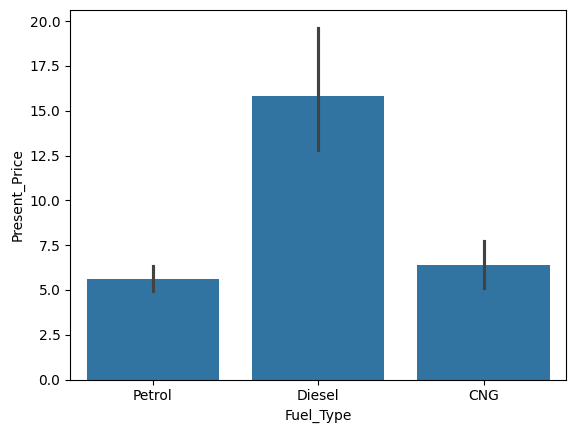

In [319]:
sns.barplot(x=df['Fuel_Type'] , y=df['Present_Price'])

## Diesel type vehicles are having more price

<Axes: xlabel='Fuel_Type', ylabel='Selling_Price'>

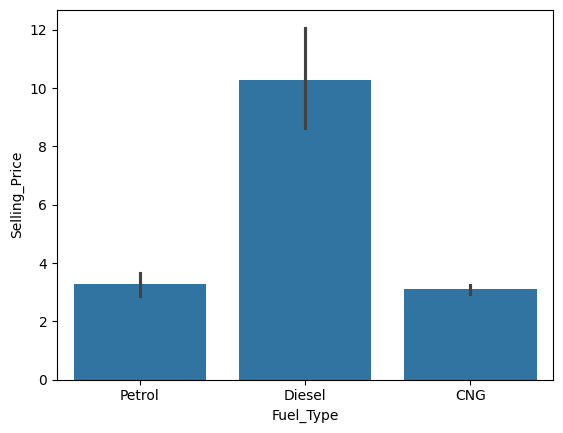

In [320]:
sns.barplot(x=df['Fuel_Type'] , y=df['Selling_Price'])

<Axes: xlabel='Selling_type', ylabel='Present_Price'>

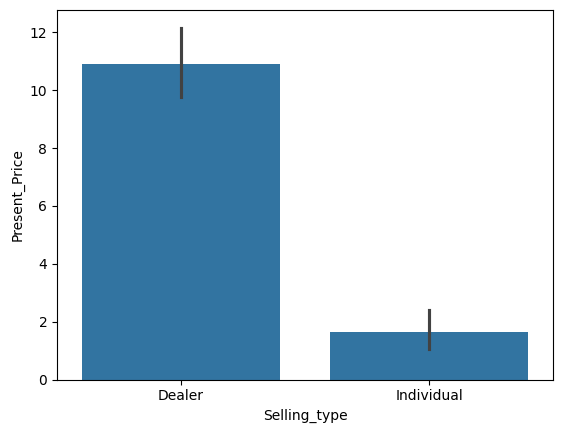

In [321]:
sns.barplot(x=df['Selling_type'] , y=df['Present_Price'])

## When the selling type is through the dealer then the price of the car increasing drastically.

<Axes: xlabel='Selling_type', ylabel='Selling_Price'>

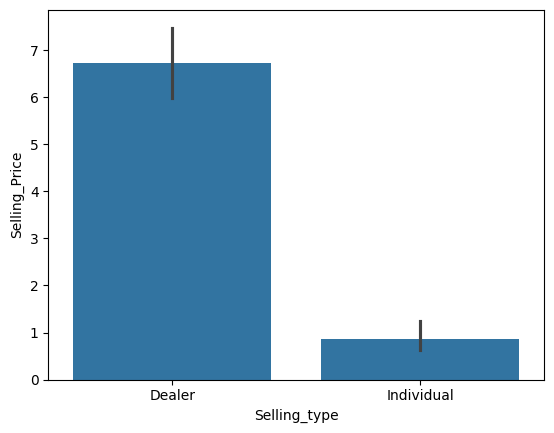

In [322]:
sns.barplot(x=df['Selling_type'] , y=df['Selling_Price'])

<Axes: xlabel='Transmission', ylabel='Present_Price'>

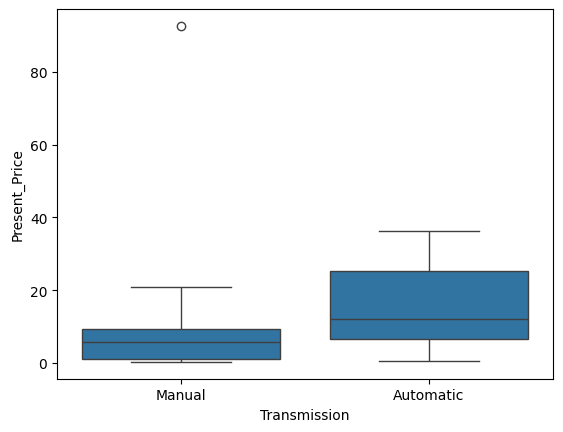

In [323]:
sns.boxplot(x=df['Transmission'] , y =df['Present_Price'])

## The vehicles which have automatic transmission are having high price.

<Axes: xlabel='Transmission', ylabel='Selling_Price'>

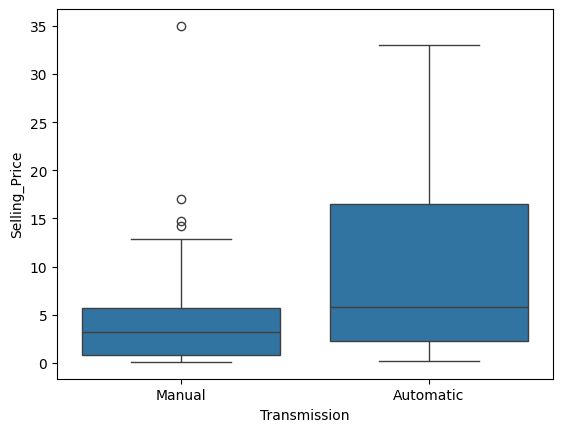

In [324]:
sns.boxplot(x=df['Transmission'] , y =df['Selling_Price'])

## Label encoding and giving weight to the values.

In [325]:
df['Fuel_Type'].unique()

array(['Petrol', 'Diesel', 'CNG'], dtype=object)

In [326]:
df['Fuel_Type'] = df['Fuel_Type'].replace({
    'Petrol' : 2,
    'Diesel' : 1,
    'CNG' : 0
 })

In [327]:
df['Fuel_Type'].value_counts()


Fuel_Type
2    239
1     60
0      2
Name: count, dtype: int64

In [328]:
df['Selling_type'].unique()

array(['Dealer', 'Individual'], dtype=object)

In [329]:
df['Selling_type'] = df['Selling_type'].replace({
    'Dealer': 1,
    'Individual' : 0
 })

In [330]:
df['Selling_type'].value_counts()


Selling_type
1    195
0    106
Name: count, dtype: int64

In [331]:
df['Transmission'] . unique()

array(['Manual', 'Automatic'], dtype=object)

In [332]:
df['Transmission'] = df['Transmission'].replace({
    'Manual': 0, 
    'Automatic' :1
})

In [333]:
df['Transmission'].value_counts()

Transmission
0    261
1     40
Name: count, dtype: int64

## Label Encoding for Car_name

In [334]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [335]:
df['Car_Name'].unique()

array(['ritz', 'sx4', 'ciaz', 'wagon', 'swift', 'vitara', 's', 'alto',
       'ertiga', 'dzire', 'ignis', '800', 'baleno', 'omni', 'fortuner',
       'innova', 'corolla', 'etios', 'camry', 'land', 'Royal', 'UM',
       'KTM', 'Bajaj', 'Hyosung', 'Mahindra', 'Honda', 'Yamaha', 'TVS',
       'Hero', 'Activa', 'Suzuki', 'i20', 'grand', 'i10', 'eon', 'xcent',
       'elantra', 'creta', 'verna', 'city', 'brio', 'amaze', 'jazz'],
      dtype=object)

In [336]:
df['Car_Name'] = le.fit_transform(df['Car_Name'])

In [337]:
df['Car_age'] = 2026 - df['Year']

In [338]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_age
0,36,2014,3.35,5.59,27000,2,1,0,0,12
1,39,2013,4.75,9.54,43000,1,1,0,0,13
2,18,2017,7.25,9.85,6900,2,1,0,0,9
3,42,2011,2.85,4.15,5200,2,1,0,0,15
4,38,2014,4.60,6.87,42450,1,1,0,0,12


<Axes: >

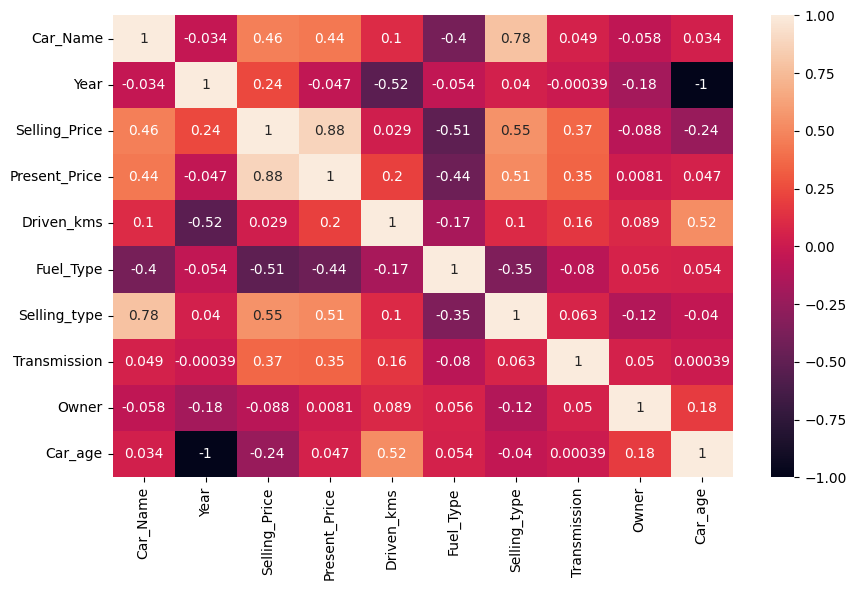

In [339]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True)

## The correlation heatmap between all the features of the dataset

### We are having many Categorical values in car_name that really creates a disturbance for label encoding or one hot encoding so let us try in 2 ways and see which model works with higher accuracy.

## Let us first perform model with Car_Name

## Let us separate the input and output features

In [340]:
x = df.drop('Selling_Price' , axis=1)
y = df['Selling_Price']

## Train_Test_Split

In [341]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Standard Scaling

In [342]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [343]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Importing the required model for Model Training

In [344]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from sklearn.linear_model import LinearRegression

### Decision Tree

In [345]:
dt = DecisionTreeRegressor(max_depth=6, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Results")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R²:", r2_score(y_test, y_pred_dt))

Decision Tree Results
MAE: 0.7170940529930196
RMSE: 1.1105257814384142
R²: 0.9464625041247331


### Random Forest

In [346]:
rf = RandomForestRegressor(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    rf, param_distributions=param_dist,
    n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1
)

random_search.fit(X_train, y_train)
best_rf = random_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("\nRandom Forest Results")
print("Best Params:", random_search.best_params_)
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R²:", r2_score(y_test, y_pred_rf))


Random Forest Results
Best Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30}
MAE: 0.5798043715846983
RMSE: 0.8935922165257116
R²: 0.9653359328159443


### XgBoost

In [347]:
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("\nXGBoost Results")
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R²:", r2_score(y_test, y_pred_xgb))


XGBoost Results
MAE: 0.5631237646497663
RMSE: 0.9279103573588956
R²: 0.9626222798672415


In [348]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_age
0,36,2014,3.35,5.59,27000,2,1,0,0,12
1,39,2013,4.75,9.54,43000,1,1,0,0,13
2,18,2017,7.25,9.85,6900,2,1,0,0,9
3,42,2011,2.85,4.15,5200,2,1,0,0,15
4,38,2014,4.60,6.87,42450,1,1,0,0,12


## Now let us peroform without carname

## Separating the input and output variables

In [349]:
x = df.drop(['Selling_Price','Car_Name' ], axis=1)
y = df['Selling_Price']

## Train_test_split

In [350]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Standard Scaling

In [351]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [352]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training

## Decision Tree

In [353]:
dt = DecisionTreeRegressor(max_depth=6, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Results")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R²:", r2_score(y_test, y_pred_dt))


Decision Tree Results
MAE: 0.827861357182455
RMSE: 1.4416628319329043
R²: 0.9097747348609232


## Random Forest

In [354]:
rf = RandomForestRegressor(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    rf, param_distributions=param_dist,
    n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1
)

random_search.fit(X_train, y_train)
best_rf = random_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("\nRandom Forest Results")
print("Best Params:", random_search.best_params_)
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R²:", r2_score(y_test, y_pred_rf))


Random Forest Results
Best Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30}
MAE: 0.6141071038251353
RMSE: 0.9318514165237023
R²: 0.9623041012172984


## Xg boost

In [355]:
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("\nXGBoost Results")
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R²:", r2_score(y_test, y_pred_xgb))


XGBoost Results
MAE: 0.6209837504488522
RMSE: 0.9891414808522297
R²: 0.9575265447125622


## Linear Regression

In [356]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R²:", r2_score(y_test, y_pred_lr))

Linear Regression Results
MAE: 1.2219323621753908
RMSE: 1.879249820797826
R²: 0.8466902419663817


## The Model which is trained without Car_Name is giving the high accuracy.

In [359]:
import joblib
joblib.dump(best_rf,"random_forest_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [358]:
x.columns

Index(['Year', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type',
       'Transmission', 'Owner', 'Car_age'],
      dtype='object')